# 01 — Explore the Data
**Eniac A/B Test | Nov 2 – Nov 16, 2021**

Four versions of the homepage "SHOP NOW / SEE DEALS" button were tested simultaneously.  
This notebook loads the raw click-tracking CSVs, extracts the key metrics, and visualises the results.

| Version | Button colour | Button text |
|---------|--------------|-------------|
| A | White | SHOP NOW |
| B | Red | SHOP NOW |
| C | White | SEE DEALS |
| D | Red | SEE DEALS |


## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})


## 2. Load the raw data

In [2]:
dfs = {
    "Version_A": pd.read_csv("../data/eniac_a.csv"),
    "Version_B": pd.read_csv("../data/eniac_b.csv"),
    "Version_C": pd.read_csv("../data/eniac_c.csv"),
    "Version_D": pd.read_csv("../data/eniac_d.csv"),
}

# Preview one file
dfs["Version_A"].head(10)


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN
5,36,a,Chargers & Cables,1261,False,NaN
6,99,a,iPhone Accessories,1226,False,NaN
7,68,a,Watch Accessories,1261,False,NaN
8,13,a,Mac Accessories,1308,False,NaN
9,15,a,AirTag,206,False,NaN


## 3. Extract visits and button clicks

Each CSV contains one row per tracked page element.  
- **Total visits** are stored in the `Snapshot information` field of the `mySidebar` element.  
- **Button clicks** are the `No. clicks` value for the `SHOP NOW` / `SEE DEALS` element.


In [3]:
def get_visits(df):
    """Parse total visit count from the Snapshot information field."""
    snap = df.loc[df["Name"] == "mySidebar", "Snapshot information"].values[0]
    # Format: "created …  •  25326 visits, …"
    visits_str = snap.split("visits")[0].split("•")[-1].strip().replace(",", "")
    return int(visits_str)

def get_clicks(df):
    """Return clicks on the CTA button (SHOP NOW or SEE DEALS)."""
    mask = df["Name"].isin(["SHOP NOW", "SEE DEALS"])
    return int(df.loc[mask, "No. clicks"].values[0])

results = pd.DataFrame({
    version: {"visits": get_visits(df), "clicks": get_clicks(df)}
    for version, df in dfs.items()
}).T.astype(int)

results["no_clicks"] = results["visits"] - results["clicks"]
results["ctr"]       = results["clicks"] / results["visits"]

results


,visits,clicks,no_clicks,ctr
Version_A,25326,512,24814,0.020216
Version_B,24747,281,24466,0.011355
Version_C,24876,527,24349,0.021185
Version_D,25233,193,25040,0.007649


## 4. Click-Through Rate per version

In [4]:
print("Click-Through Rates")
print("=" * 40)
for version, row in results.sort_values("ctr", ascending=False).iterrows():
    bar = "█" * int(row["ctr"] * 1000)
    print(f"  {version}  {row['ctr']:.4f} ({row['ctr']*100:.2f}%)  {bar}")


Click-Through Rates
  Version_C  0.0212 (2.12%)  █████████████████████
  Version_A  0.0202 (2.02%)  ████████████████████
  Version_B  0.0114 (1.14%)  ███████████
  Version_D  0.0076 (0.76%)  ███████


## 5. Visualise the results

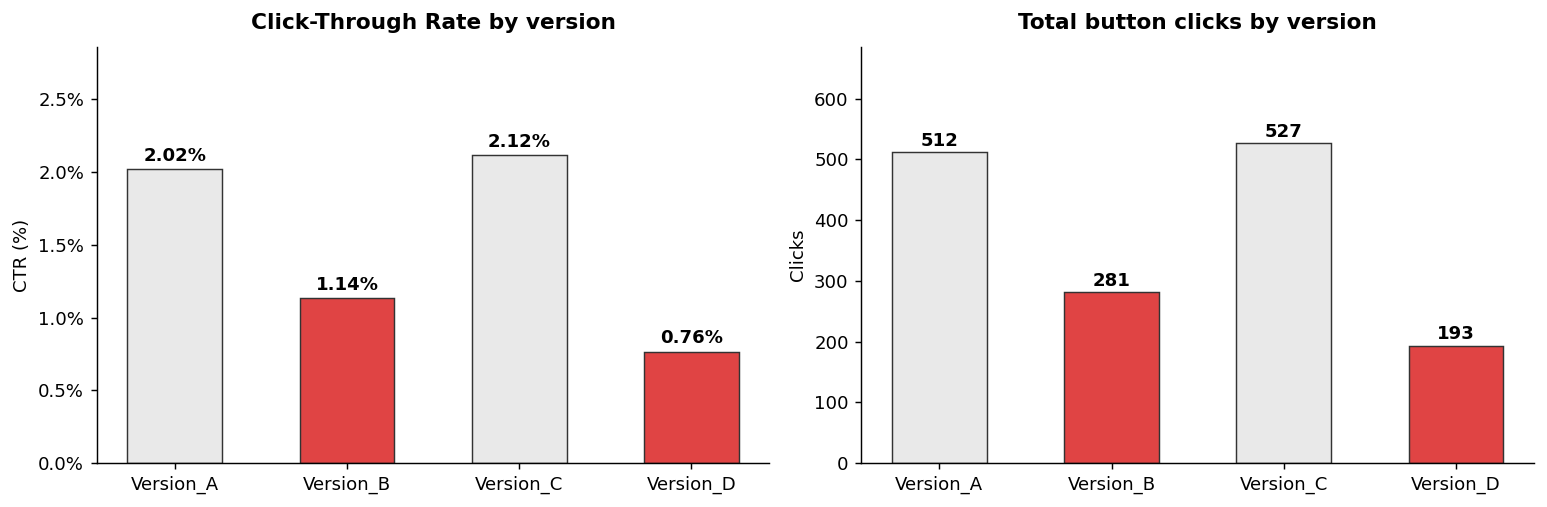

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

versions  = results.index.tolist()
ctrs      = (results["ctr"] * 100).tolist()
colours   = ["#e9e9e9", "#e04444", "#e9e9e9", "#e04444"]   # white / red variants
edge_col  = ["#333333"] * 4

# ── CTR bar chart ─────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(versions, ctrs, color=colours, edgecolor=edge_col, linewidth=0.8, width=0.55)
ax.set_title("Click-Through Rate by version", fontsize=12, fontweight="bold", pad=10)
ax.set_ylabel("CTR (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.set_ylim(0, max(ctrs) * 1.35)
for bar, val in zip(bars, ctrs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{val:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Absolute clicks bar chart ──────────────────────────────────────────────
ax2 = axes[1]
clicks = results["clicks"].tolist()
bars2  = ax2.bar(versions, clicks, color=colours, edgecolor=edge_col, linewidth=0.8, width=0.55)
ax2.set_title("Total button clicks by version", fontsize=12, fontweight="bold", pad=10)
ax2.set_ylabel("Clicks")
ax2.set_ylim(0, max(clicks) * 1.3)
for bar, val in zip(bars2, clicks):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
             str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("../images/ctr_comparison.png", bbox_inches="tight")
plt.show()


## 6. Observations

**Key findings from the data exploration:**

- **Version C** (white "SEE DEALS") achieved the highest CTR at **~2.12%**, narrowly ahead of Version A.
- **Version A** (white "SHOP NOW", original) came second at **~2.02%**.
- **Version B** (red "SHOP NOW") performed noticeably worse at **~1.14%**.
- **Version D** (red "SEE DEALS") had the lowest CTR at **~0.76%** — less than half the control.

The results suggest that **button colour has a much larger impact than button text**.  
Red buttons appear to actively deter clicks. Whether these differences are statistically significant  
will be determined in `02_chi_square_test.ipynb`.
